## _(3) - Segmenting Stage_

In [1]:
import glob, os, sys, yaml

In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
pp = pprint.PrettyPrinter(indent=2)
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
os.environ['EXATRKX_DATA'] = os.path.abspath(os.curdir)

### _3.1 - Config File_

In [6]:
# load processing config file (trusted source)
config_path = 'LightningModules/Segmenting/configs/segment_quickstart.yaml'
config_file = os.path.join(os.curdir, config_path)
with open(config_file) as f:
    try:
        config = yaml.load(f, Loader=yaml.FullLoader) # equiv: yaml.full_load(f)
    except yaml.YAMLError as e:
        print(e)

### _3.2 - Input Data_

In [7]:
# fetch all files
inputdir = '../ctd2022/run_all/gnn_evaluation/test'
gnn_files = sorted(glob.glob(os.path.join(inputdir, "*")))

In [8]:
event_idx = 1

In [9]:
gnn_data = torch.load(gnn_files[event_idx], map_location=device)
print("Length of Data: {}".format(len(gnn_data)))

Length of Data: 11


In [10]:
gnn_data

Data(x=[171, 3], pid=[171], layers=[171], event_file='/global/cscratch1/sd/aakram/train_all/event0000095001', hid=[171], pt=[171], modulewise_true_edges=[2, 160], layerwise_true_edges=[2, 172], edge_index=[2, 808], y_pid=[808], scores=[1616])

In [11]:
gnn_data.x[:10]

tensor([[ 0.1663,  0.0097,  0.0036],
        [ 0.1663, -0.6570,  0.0022],
        [ 0.1669,  0.6956,  0.0025],
        [ 0.1669, -0.3623,  0.0018],
        [ 0.1669,  0.6956,  0.0020],
        [ 0.1669, -0.6377,  0.0019],
        [ 0.1681,  0.2853,  0.0032],
        [ 0.1681, -0.7147,  0.0033],
        [ 0.1681,  0.6187,  0.0019],
        [ 0.1723, -0.9150,  0.0009]], grad_fn=<SliceBackward0>)

In [12]:
gnn_data.event_file

'/global/cscratch1/sd/aakram/train_all/event0000095001'

In [13]:
type(gnn_data.y_pid)

torch.Tensor

### _3.3 - Segmentation_

### _(a) - Connected Components Labelling (CCL)_

In [14]:
import scipy.sparse as sp
import scipy.sparse.csgraph as scigraph
from torch_geometric.utils import to_scipy_sparse_matrix

In [15]:
# from LightningModules.Segmenting import label_graph_ccl

def label_graph(input_file, edge_cut=0.5):
    """loads an input_file and outputs a segmented/labelled graph"""
    
    # load graph
    graph = torch.load(input_file, map_location=device)
    
    # apply cut
    # passing_edges = graph.edge_index[:, graph.scores > edge_cut]
    passing_edges = graph.edge_index[:, graph.scores[:graph.edge_index.shape[1]] > edge_cut]
    
    # get connected components
    sparse_edges = sp.coo_matrix(
        (np.ones(passing_edges.shape[1]), passing_edges.cpu().numpy()),
        shape=(len(graph.x), len(graph.x)),
    )
    
    # use to_scipy_sparse_matrix() for brevity (worked)
    # sparse_edges = to_scipy_sparse_matrix(passing_edges)
    
    connected_components = scigraph.connected_components(sparse_edges)[1]

    # attach labels to data
    graph.labels = connected_components
    
    return graph

In [16]:
graph = torch.load(gnn_files[event_idx], map_location=device)

In [17]:
labeled_graph = label_graph(gnn_files[event_idx], edge_cut=0.5)

In [18]:
labeled_graph.labels

array([0, 1, 2, 3, 2, 1, 4, 5, 6, 7, 0, 2, 1, 2, 5, 3, 1, 4, 6, 7, 2, 2,
       3, 1, 1, 0, 5, 6, 4, 7, 7, 2, 1, 0, 2, 5, 1, 3, 1, 6, 4, 7, 2, 2,
       1, 1, 0, 5, 3, 6, 4, 4, 7, 0, 1, 5, 1, 1, 3, 2, 2, 6, 4, 4, 7, 0,
       2, 1, 1, 3, 2, 5, 6, 7, 0, 4, 1, 5, 2, 2, 1, 3, 6, 4, 7, 4, 4, 2,
       5, 2, 1, 0, 3, 6, 5, 2, 2, 1, 1, 6, 0, 3, 7, 2, 5, 2, 1, 0, 3, 6,
       1, 1, 5, 2, 7, 2, 1, 0, 3, 6, 1, 5, 2, 1, 2, 7, 0, 6, 3, 1, 5, 2,
       1, 2, 7, 0, 6, 3, 5, 2, 1, 1, 2, 6, 7, 1, 3, 0, 5, 2, 2, 1, 6, 0,
       3, 7, 1, 5, 2, 2, 1, 6, 0, 3, 1, 7, 5, 2, 2, 1, 1], dtype=int32)

- lets test to_scipy_sparse_matrix() for brevity

In [19]:
# test PyG::to_scipy_sparse_matrix() for brevity
passing_edges = graph.edge_index[:, graph.scores[:graph.edge_index.shape[1]] > 0.5]
sparse_edges = to_scipy_sparse_matrix(passing_edges)
connected_components = scigraph.connected_components(sparse_edges)[1]
graph.labels = connected_components

In [20]:
graph.labels

array([0, 1, 2, 3, 2, 1, 4, 5, 6, 7, 0, 2, 1, 2, 5, 3, 1, 4, 6, 7, 2, 2,
       3, 1, 1, 0, 5, 6, 4, 7, 7, 2, 1, 0, 2, 5, 1, 3, 1, 6, 4, 7, 2, 2,
       1, 1, 0, 5, 3, 6, 4, 4, 7, 0, 1, 5, 1, 1, 3, 2, 2, 6, 4, 4, 7, 0,
       2, 1, 1, 3, 2, 5, 6, 7, 0, 4, 1, 5, 2, 2, 1, 3, 6, 4, 7, 4, 4, 2,
       5, 2, 1, 0, 3, 6, 5, 2, 2, 1, 1, 6, 0, 3, 7, 2, 5, 2, 1, 0, 3, 6,
       1, 1, 5, 2, 7, 2, 1, 0, 3, 6, 1, 5, 2, 1, 2, 7, 0, 6, 3, 1, 5, 2,
       1, 2, 7, 0, 6, 3, 5, 2, 1, 1, 2, 6, 7, 1, 3, 0, 5, 2, 2, 1, 6, 0,
       3, 7, 1, 5, 2, 2, 1, 6, 0, 3, 1, 7, 5, 2, 2, 1, 1], dtype=int32)

In [21]:
labeled_graph.labels == graph.labels

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [22]:
np.where(labeled_graph.labels==0)[0]

array([  0,  10,  25,  33,  46,  53,  65,  74,  91, 100, 107, 117, 126,
       135, 147, 153, 162])

### _(b) - DBSCAN Labelling_

In [23]:
from LightningModules.Segmenting import label_graph_dbscan

### _(c) - Wrangler Labelling_

In [24]:
import networkx as nx
from torch_geometric.utils import to_networkx
from LightningModules.Segmenting import get_tracks

In [25]:
G = to_networkx(graph, node_attrs=['x'], edge_attrs=['scores', 'y_pid'])

In [26]:
G.nodes[0]['x'][2]

0.0035587300080806017

In [27]:
nx_graph = get_tracks(G, th=0.1, th_re=0.8, feature_name='scores', with_fit=False)

In [28]:
nx_graph

In [29]:
from src.drawing import detector_layout
from src.utils_math import polar_to_cartesian

In [30]:
# from https://github.com/exatrkx/exatrkx-neurips19/blob/master/gnn-tracking/heptrkx/nx_graph/utils_plot.py
def get_pos(Gp):
    pos = {}
    for node in Gp.nodes():
        # r, phi, z = Gp.node[node]['pos'][:3]
        r, phi = G.nodes[node]['x'][:2]
        
        theta = phi * np.pi
        x = r * np.cos(theta)*100
        y = r * np.sin(theta)*100

        pos[node] = np.array([x, y])
    return pos

def plot_networkx(G, ax=None, i=0, only_true=False):
    """G is networkx graph,
    node feature: {'pos': [r, phi, z]}
    edge feature: {"solution": []}
    """
    if ax is None:
        fig, ax = plt.subplots()

    n_edges = len(G.edges())
    edge_colors = [0.]*n_edges
    true_edges = []
    for iedge, edge in enumerate(G.edges(data=True)):
        if int(edge[2]['y_pid']) == 1:
            edge_colors[iedge] = 'r'
            true_edges.append((edge[0], edge[1]))
        else:
            edge_colors[iedge] = 'grey'

    Gp = nx.edge_subgraph(G, true_edges) if only_true else G
    edge_colors = ['k']*len(true_edges) if only_true else edge_colors 

    pos = get_pos(Gp)

    nx.draw_networkx(Gp, pos, arrows=False, with_labels=False, ax=ax, 
                     node_color='#A0CBE2', edge_color=edge_colors,
                     width=3, node_size=10, label='tracks {}'.format(i))
    
    # plt.savefig("Graph.png", format="PNG")

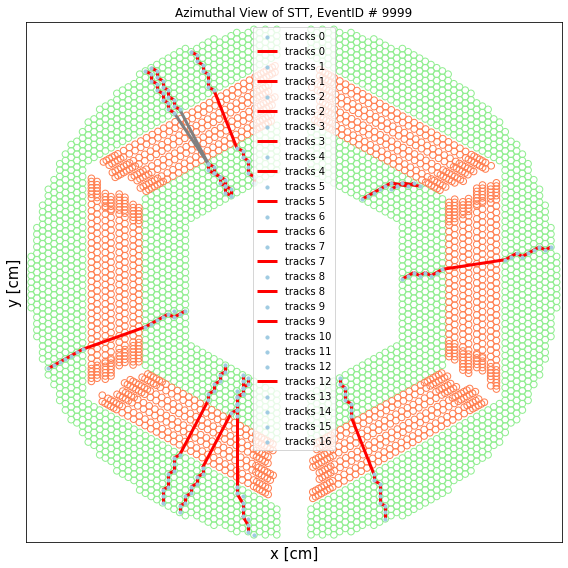

In [31]:
# plot reco event from CCL
fig, ax = detector_layout(figsize=(8,8))

for i, graph in enumerate(nx_graph):
    plot_networkx(graph, ax, i)

ax.set_title('Azimuthal View of STT, EventID # {}'.format(9999))
ax.legend(fontsize=10, loc='best')
fig.tight_layout()
# fig.savefig("reco_track.png")

- Convert _NetworkX_ to _PyG_ Graph

In [32]:
from torch_geometric.utils.convert import from_networkx

In [33]:
pyg_graph = from_networkx(nx_graph[0])

In [34]:
pyg_graph

Data(x=[17, 3], edge_index=[2, 16], scores=[16], y_pid=[16])

In [35]:
pyg_graph.edge_index

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 12, 13, 14, 15, 16],
        [ 4,  3,  5,  8,  6,  7,  9, 10, 11, 13, 12, 15, 14,  1, 16,  2]])

In [36]:
pyg_graph.scores

tensor([0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999,
        0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999])

In [37]:
pyg_graph.y_pid

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])

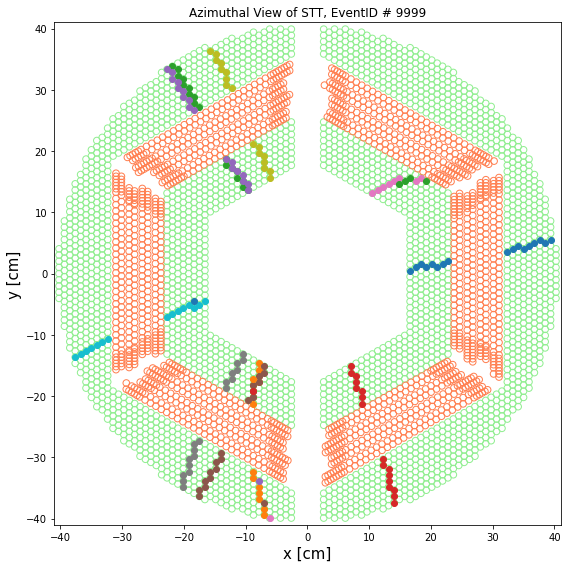

In [38]:
# plot reco event from CCL
fig, ax = detector_layout(figsize=(8,8))
#t_ids = np.unique(reco_track.track_id)

# here, (x,y,ir) comes from the true event,
# but idx comes from reco event from CCL

for graph in nx_graph:
    pyg_graph = from_networkx(graph)
    r, phi, ir = pyg_graph.x.T
    ir = ir.detach().numpy()*100
    x, y = polar_to_cartesian(r.detach().numpy(), phi.detach().numpy())
    
    ax.scatter(x, y)
    
    #idx = reco_track.track_id == tid
    #ax.plot(x[idx], y[idx], '-', linewidth=2)
    #ax.scatter(x[idx], y[idx], label='particle_id: {}'.format(tid))
    
ax.set_title('Azimuthal View of STT, EventID # {}'.format(9999))
# ax.legend(fontsize=10, loc='best')
fig.tight_layout()
# fig.savefig("reco_track.png")